In [3]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.objectives.logistic import LogisticRegressionObjective
from src.objectives.simple_llm import SimpleLLMObjective

from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

from src.schedulers.independent_local_sgd_pipeline import IndependentLocalSGDScheduler
from src.methods.localSGD import LocalMinibatchSGD1F1BMethod

In [5]:
def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )

def make_local_sgd_method(
    lr: float,
    timeline,
    num_runs: int,
    local_steps: int,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return LocalMinibatchSGD1F1BMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        num_runs=num_runs,
        local_steps=local_steps,
        init_stage_weights=init_stage_weights,
        name=name or f"LocalSGD lr={lr:.3e}",
    )

def run_trials(objective, method_factory, seeds):
    traces = []
    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)
    return traces


def aggregate_time_curves(traces):
    curves = []
    for tr in traces:
        # We now use the trace that records the objective at every single Time Step
        curve = tr.objective_trace
        if curve is None:
            raise ValueError(f"{tr.method_name} has no objective_trace.")
        curves.append(curve)
        
    curves = np.stack(curves, axis=0)
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_time_curves(traces)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"], # The loss at the very last time step
            "final_std": agg["final_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]
        label = f"lr={lr:.3e}"
        if np.isclose(lr, sweep_result["best_lr"]):
            label += "  [best]"
            lw = 2.8
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("Time Step (Timeline execution step)")
    plt.ylabel("full objective")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()

In [6]:
# problem setup
num_stages = 16

num_parameters = 1024*2

batch_size = 1
total_batches = 50
num_epochs = 5
seed = 0
gradient_noise_std = 0.5

num_examples = batch_size * total_batches
num_microbatches = total_batches * num_epochs

'''
objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    gradient_noise_std=gradient_noise_std,
    kind="tridiagonal",
    #condition_number=10
)
'''


objective = LogisticRegressionObjective.synthetic(
    num_examples=batch_size * total_batches,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    l2_reg=1e-4,  # Optional L2 regularization
    gradient_noise_std=gradient_noise_std
)

'''
text_data = "hello world " * 10 
seq_len = 8
objective = SimpleLLMObjective(
    text_data=text_data,
    num_stages=num_stages,
    batch_size=batch_size,
    seq_len=seq_len,
    embed_dim=32,
    num_heads=2,
)
'''


# 1. PipeDream Timeline
pd_scheduler = PipeDream1F1BScheduler(noam=num_stages)
pd_timeline = pd_scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

# 2. Local SGD Timeline
# To hide the pipeline bubbles best, M should be close to num_stages.
# 2. Local SGD Timeline
M = num_stages  # Number of independent parallel runs (e.g., 10)
K = 5          # Number of local steps each run takes BEFORE syncing

round_size = M * K  # 10 * 3 = 30 microbatches per round

# Ensure total microbatches is a perfect multiple of round_size
# (If num_microbatches was 300, 300 // 30 = 10 full rounds of synchronization)
num_rounds = num_microbatches // round_size
#num_microbatches = num_rounds * round_size 

print(f"Local SGD Setup: M={M} runs, K={K} local steps")
print(f"Total Rounds: {num_rounds} (Syncing weights {num_rounds} times!)")
print(f"Total Microbatches: {num_microbatches}")

local_sgd_scheduler = IndependentLocalSGDScheduler(num_runs=M, local_steps=K)
local_sgd_timeline = local_sgd_scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)
init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

num_dataset_batches = len(objective.get_batches())
training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)

L = objective.smoothness_constant
print("L =", L)
print("1/L =", 1 / L)

Local SGD Setup: M=16 runs, K=5 local steps
Total Rounds: 3 (Syncing weights 3 times!)
Total Microbatches: 250
num_dataset_batches = 50
effective epochs    = 5.0
L = 13.54012915911477
1/L = 0.0738545392181014


PD timeline steps = 530


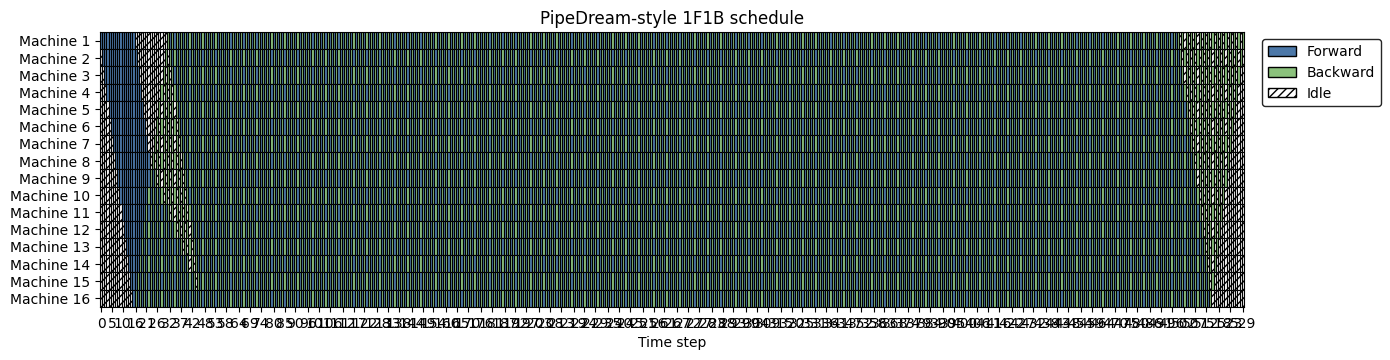

In [7]:
fig, ax = plot_schedule(pd_timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
print("PD timeline steps =", len(pd_timeline))
plt.show()

Local Minibatch SGD timeline steps = 620


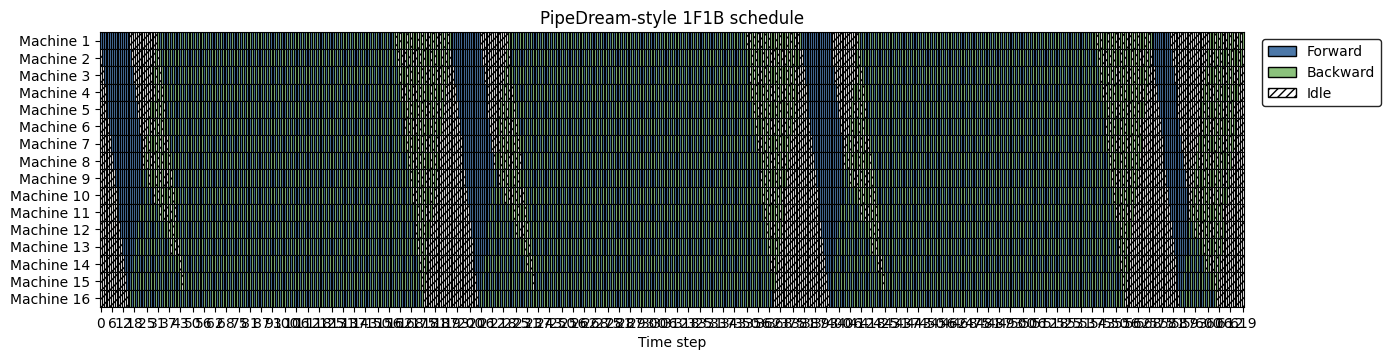

In [8]:
fig, ax = plot_schedule(local_sgd_timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
print("Local Minibatch SGD timeline steps =", len(local_sgd_timeline))
plt.show()

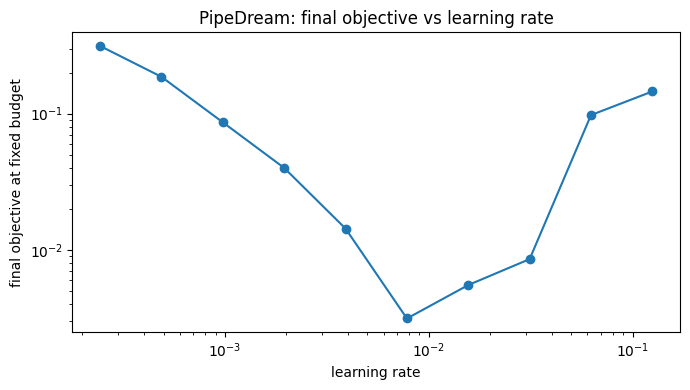

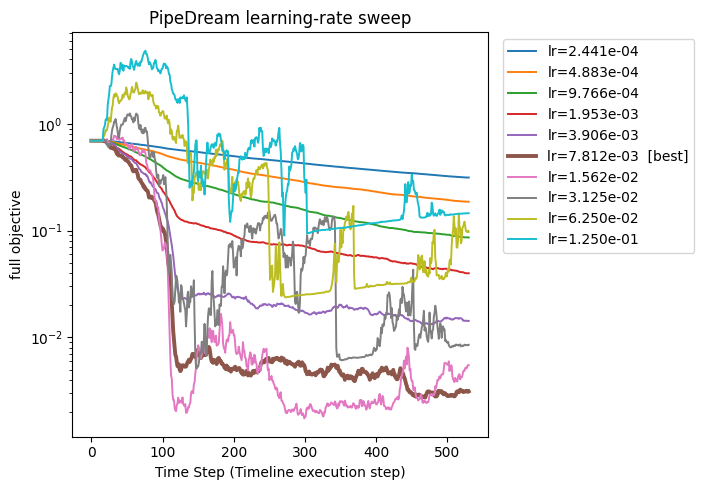

In [9]:
pd_gamma_grid = (2.0 ** np.arange(-12, -2))

# ==========================================
# 1. SWEEP PIPEDREAM
# ==========================================
pd_sweep = sweep_learning_rates(
    objective=objective, 
    method_name="PipeDream", 
    learning_rates=pd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr, 
        timeline=pd_timeline, 
        training_batch_indices=training_batch_indices, 
        init_stage_weights=init_stage_weights,
    ),
    seeds=[0],
)
plot_lr_sweep_summary(pd_sweep, title="PipeDream: final objective vs learning rate")
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

/Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project/src/objectives/logistic.py:16: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + np.exp(-x)),
/Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project/src/objectives/logistic.py:17: RuntimeWarning: overflow encountered in exp
  np.exp(x) / (1.0 + np.exp(x)))
/Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project/src/objectives/logistic.py:17: RuntimeWarning: invalid value encountered in divide
  np.exp(x) / (1.0 + np.exp(x)))


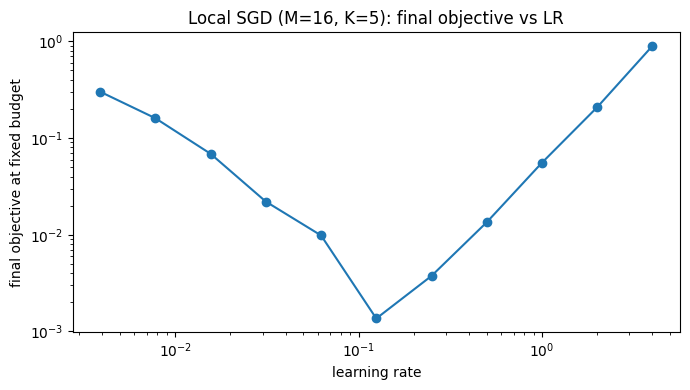

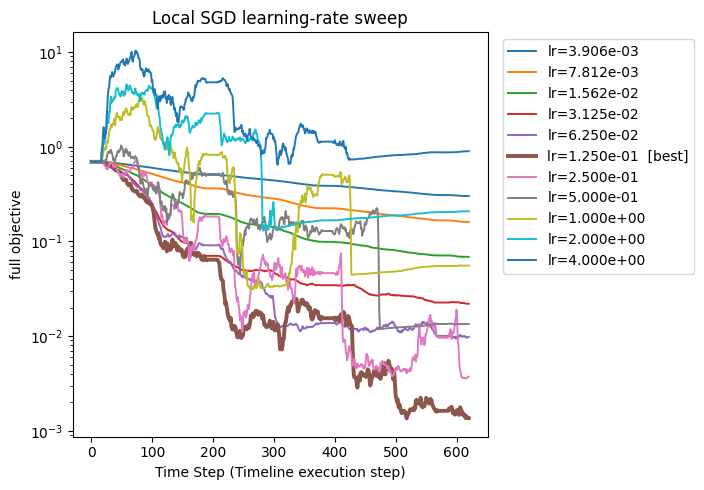

In [10]:
local_sgd_gamma_grid = (2.0 ** np.arange(-8, 3))

# ==========================================
# 3. SWEEP LOCAL SGD
# ==========================================
# Local SGD does not suffer from staleness, so it can typically handle 
# larger learning rates, similar to GPD/Standard SGD.
local_sgd_sweep = sweep_learning_rates(
    objective=objective, 
    method_name="LocalSGD", 
    learning_rates=local_sgd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_local_sgd_method(
        lr=lr, 
        timeline=local_sgd_timeline, 
        num_runs=M, 
        local_steps=K, 
        training_batch_indices=training_batch_indices, 
        init_stage_weights=init_stage_weights,
    ),
    seeds=[0],
)
plot_lr_sweep_summary(local_sgd_sweep, title=f"Local SGD (M={M}, K={K}): final objective vs LR")
plot_lr_sweep_curves(
    local_sgd_sweep,
    title="Local SGD learning-rate sweep",
    log_scale=True,
)

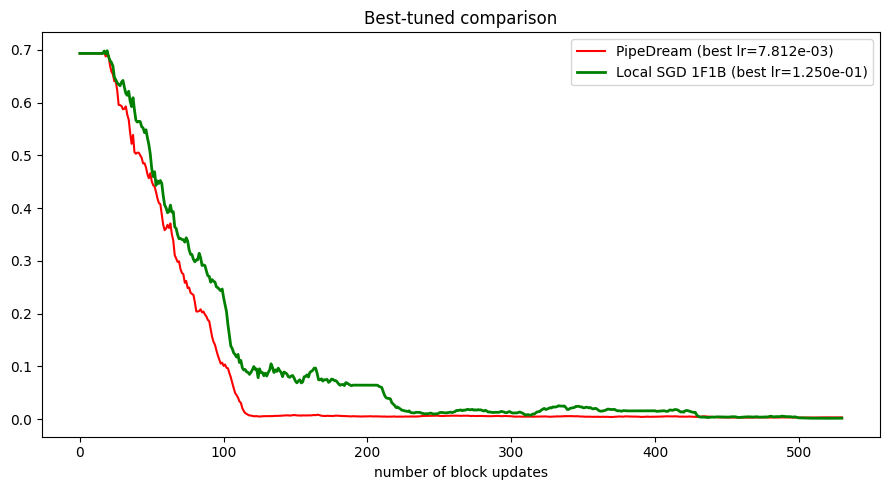

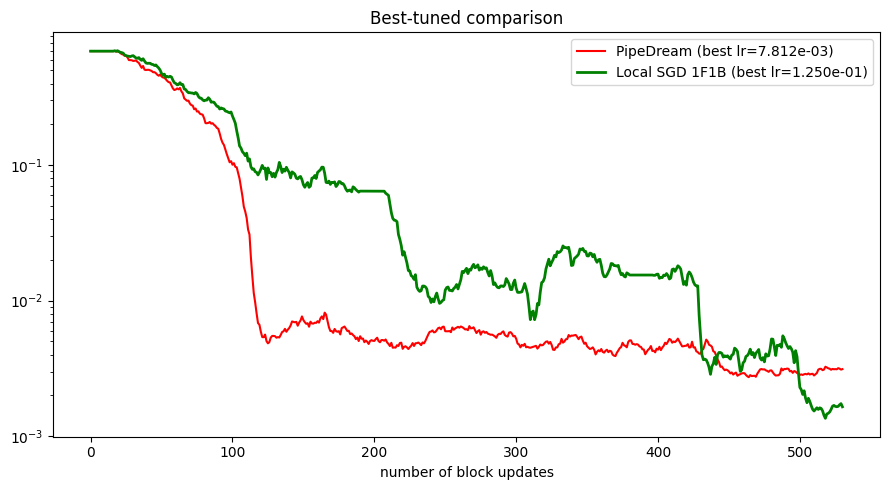

In [11]:
# ==========================================
# FINAL BEST-TUNED COMPARISON PLOTS
# ==========================================
best_pd_curve = pd_sweep["best_curve"]
best_local_sgd_curve = local_sgd_sweep["best_curve"]

T = min(len(best_pd_curve), len(best_local_sgd_curve))

# Linear Scale Plot
plt.figure(figsize=(9, 5))
plt.plot(best_pd_curve[:T], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')
plt.plot(best_local_sgd_curve[:T], label=f"Local SGD 1F1B (best lr={local_sgd_sweep['best_lr']:.3e})", color='green', linewidth=2)
plt.xlabel("number of block updates")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Log Scale Plot
plt.figure(figsize=(9, 5))
eps = 1e-16
plt.semilogy(np.maximum(best_pd_curve[:T], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')
plt.semilogy(np.maximum(best_local_sgd_curve[:T], eps), label=f"Local SGD 1F1B (best lr={local_sgd_sweep['best_lr']:.3e})", color='green', linewidth=2)
plt.xlabel("number of block updates")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

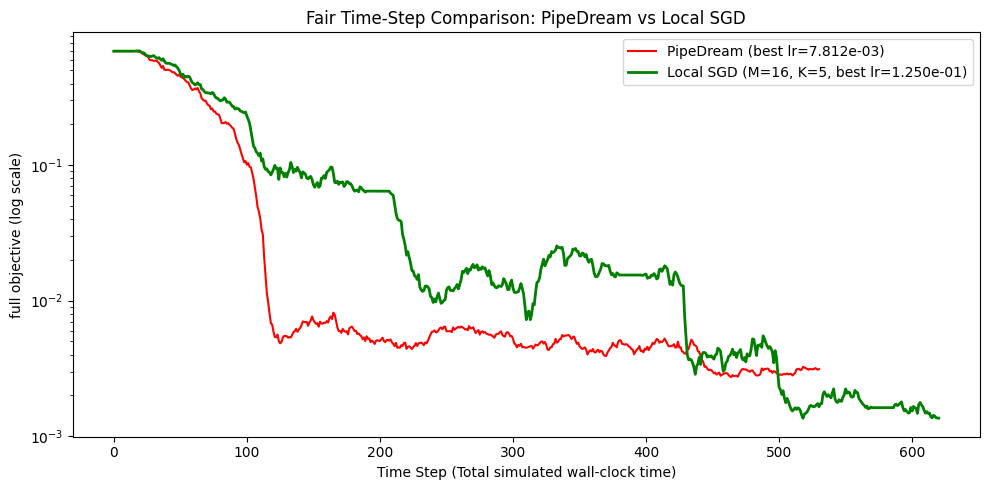

In [12]:
# ==========================================
# PLOT FAIR COMPARISON OVER TIME
# ==========================================
best_pd_curve = pd_sweep["best_curve"]
best_local_sgd_curve = local_sgd_sweep["best_curve"]

plt.figure(figsize=(10, 5))
eps = 1e-16

# Because we plot against np.arange(len(curve)), the X-axis is the exact Time Step!
plt.semilogy(np.arange(len(best_pd_curve)), np.maximum(best_pd_curve, eps), 
             label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})", color='red')

plt.semilogy(
    np.arange(len(best_local_sgd_curve)), np.maximum(best_local_sgd_curve, eps), 
    label=f"Local SGD (M={M}, K={K}, best lr={local_sgd_sweep['best_lr']:.3e})", 
    color='green', 
    linewidth=2
)

plt.xlabel("Time Step (Total simulated wall-clock time)")
plt.ylabel("full objective (log scale)")
plt.title("Fair Time-Step Comparison: PipeDream vs Local SGD")
plt.legend()
plt.tight_layout()
plt.show()

# Different K

In [13]:
# =====================================================================
# SWEEP OVER K FOR LOCAL SGD
# =====================================================================
M = num_stages

# We choose K values that evenly divide the 300 microbatches.
# M * K must divide 300 cleanly to ensure no partial rounds at the end.
# Since M=10, K can be 1, 2, 3, 5, 6, 10. Let's pick a diverse set:
K_values = [1, 2, 5, 15, 30]

local_sgd_results = {}

for K in K_values:
    # 1. Generate Timeline for this K
    lsgd_scheduler = IndependentLocalSGDScheduler(num_runs=M, local_steps=K)
    lsgd_timeline = lsgd_scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)
    
    # 2. Sweep LR
    method_label = f"LocalSGD (K={K})"
    sweep_result = sweep_learning_rates(
        objective=objective,
        method_name=method_label,
        learning_rates=local_sgd_gamma_grid,
        method_factory_builder=lambda lr, seed: make_local_sgd_method(
            lr, lsgd_timeline, M, K, training_batch_indices, init_stage_weights
        ),
        seeds=[0],
    )
    local_sgd_results[K] = sweep_result

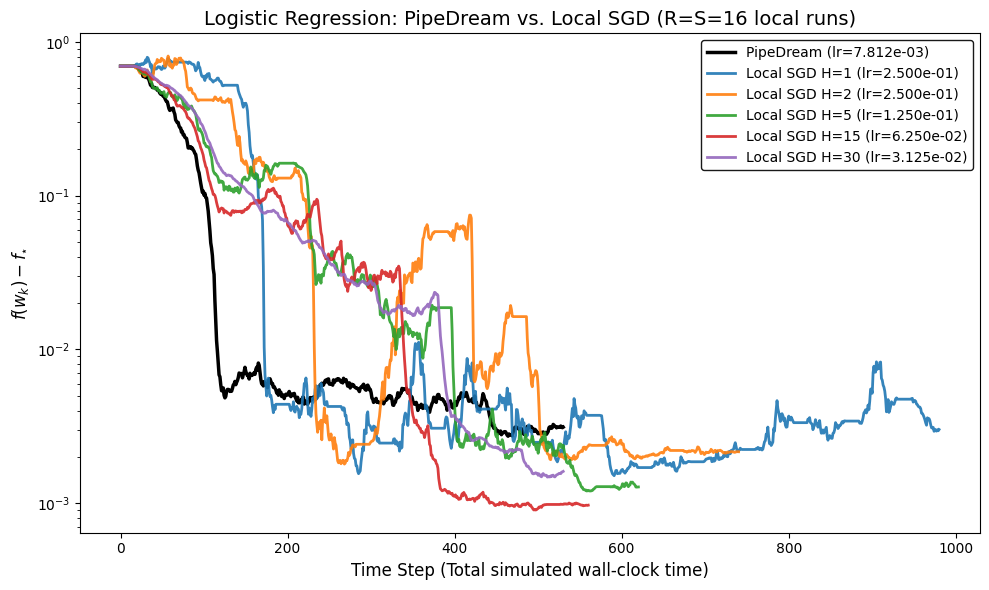

In [14]:
# =====================================================================
# PLOT ALL TUNED CURVES
# =====================================================================
plt.figure(figsize=(10, 6))
eps = 1e-16

# Plot PipeDream
pd_curve = pd_sweep["best_curve"]
plt.semilogy(
    np.arange(len(pd_curve)), np.maximum(pd_curve, eps), 
    label=f"PipeDream (lr={pd_sweep['best_lr']:.3e})", 
    color='black', linewidth=2.5, linestyle='-'
)

# Plot Local SGD for each K
colors = {
    1: '#1f77b4',   # blue
    2: '#ff7f0e',   # orange
    5: '#2ca02c',   # green
    15: '#d62728',  # red
    30: '#9467bd',   # purple
    40: '#8c564b'   # brown
}
for K in K_values:
    res = local_sgd_results[K]
    curve = res["best_curve"]
    plt.semilogy(
        np.arange(len(curve)), np.maximum(curve, eps), 
        label=f"Local SGD H={K} (lr={res['best_lr']:.3e})", 
        color=colors[K], linewidth=2, alpha=0.9
    )

plt.xlabel("Time Step (Total simulated wall-clock time)", fontsize=12)
plt.ylabel(r"$f(w_k) - f_{\star}$", fontsize=12)
plt.title(f"Logistic Regression: PipeDream vs. Local SGD (R=S={M} local runs)", fontsize=14)
plt.legend(loc="upper right", framealpha=0.9, edgecolor='black')
#plt.grid(True, which="both", ls="-", alpha=0.2)


max_time_step = 2000  
#plt.xlim(0, max_time_step) 
#plt.ylim(1e-2, None) 

plt.tight_layout()

plt.savefig(f"pipedream_vs_local_sgd_{num_stages}_stages.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Scaling of PD and RPD with $S$